In [1]:
import cv2
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from utils.plot import *

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

In [2]:
# ----- Utils -----

In [3]:
def train(model, train_loader, optimizer):

    model.train()
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))


def evaluate(model, test_loader):

    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim=True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, test_accuracy

In [4]:
# ----- CIFAR-10 Data Augmentation -----
# input image shape: (32,32,3)

In [5]:
def gaussian_smoothing(image, filter_size=3, sigma=1.0):
    """
    Inputs
    - image: an input image of shape (32,32,3).
    Returns
    - image: image blurred with a Gaussian Filter.
    """
    center = (filter_size-1)/2
    gaussian_filter = np.zeros((filter_size, filter_size))
    for row in range(filter_size):
        for col in range(filter_size):
            gaussian_filter[row, col] = np.exp((-(row-center) ** 2 - (col-center) ** 2) / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
    gaussian_filter = gaussian_filter / np.sum(gaussian_filter)
    image = cv2.filter2D(image, -1, gaussian_filter) # 필터 적용

    return image


def color_jitter(image):
    """
    Inputs
    - image: an input image of shape (32,32,3).
    Returns
    - image: image blurred with a Gaussian Filter.
    """
    image = cv2.convertScaleAbs(image, alpha=1.5, beta=20)

    return image


def custom_augmentation(image): 
    """
      Inputs
      - image: an input image of shape (32,32,3).
      Returns
      - image: image after applying your custom augmentation.
    """
#     1. Rotate 
#     width = image.shape[0]
#     height = image.shape[1]
#     rotation_matrix = cv2.getRotationMatrix2D((width/2,height/2),45,.5)
#     image = cv2.warpAffine(image,rotation_matrix,(width,height))
#.    2. Flip 
    image = cv2.flip(image,3)

    return image

Files already downloaded and verified


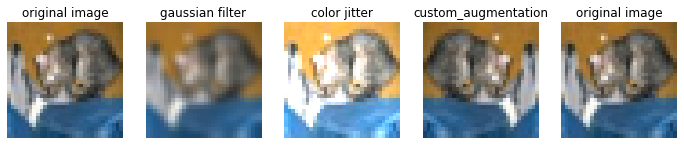

In [6]:
# matplotlib의 imshow를 쓸 때 커널이 죽는 경우에 사용
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# 확인용
raw_test = datasets.CIFAR10(root="./data/CIFAR_10", train=False, download=True)

f, ax = plt.subplots(1, 5)
f.set_size_inches(12, 3)
x = raw_test[0][0]
x = np.array(x)
g = gaussian_smoothing(x)
j = color_jitter(x)
c = custom_augmentation(x)
title = ['original image', 'gaussian filter', 'color jitter', 'custom_augmentation', 'original image']
for i, img in enumerate([x, g, j, c, x]):
    ax[i].imshow(img)
    ax[i].axis('off')
    ax[i].set_title(title[i], color='k')

In [7]:
# ----- Load dataset -----

In [7]:
class CustomDataset(Dataset):
    def __init__(self, train, prob=0.5, data_dir="./data/CIFAR_10"):

        self.data = datasets.CIFAR10(root=data_dir, train=train, download=True)
        self.prob = prob

        
    def __len__(self):
        return len(self.data)
    
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    
    def transform(self, image):
        """
        Inputs
          - image: numpy array of an input image of shape (32,32,3).
        Returns
          - image: numpy array of the augmented input image with shape (32,32,3)
        """
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # Convert the given RGB image into BGR scale
        
        if self.prob != 0:
            if np.random.rand() > self.prob :
                func = np.random.randint(3)
                aug = [gaussian_smoothing, color_jitter, custom_augmentation]
                image = aug[func](image)
                
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert the augmented image back to RGB scale for training
        
        return image

    def collate_fn(self, data):
        """
        Inputs
        - list of tuples, each containing a PIL image and an integer label
        - number of tuples in the list == BATCH SIZE
        Returns
        - batch of image tensors, batch of label tensors
        - size: (BATCH, CHANNEL, HEIGHT, WIDTH), (BATCH)
        """
        batch_x, batch_y = [], []
        
        for x, y, in data:
            x = np.array(x) # Convert each image in the batch from PIL image to numpy array 
            if self.transform is not None: # Transform the image using self.transform method to apply random augmentation
                x = self.transform(x)
            x = x/255 # Normalize the transformed image by mapping the range [0, 255] to range [0, 1]
            x = torch.Tensor([x]) # Convert the batch of preprocessed images into PyTorch float tensors
            x = x.view([3, 32, 32])# (H * W * C) to (C * H * W)
            y = torch.Tensor([y]) # Convert the batch of labels into PyTorch long tensors
            batch_x.append(x)
            batch_y.append(y)      
        
        # batch_x, batch_y를 list에서 tensor로 바꾸기
        batch_x = torch.stack(batch_x).float()
        batch_y = torch.cat(batch_y).long()

        return batch_x, batch_y

Files already downloaded and verified


<ipython-input-7-c4f5434ff2ad>:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:204.)
  x = torch.Tensor([x]) # Convert the batch of preprocessed images into PyTorch float tensors


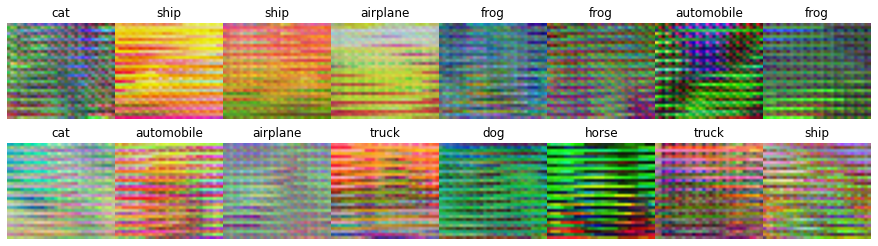

In [8]:
# without applying data augmentation
raw_test_dataset = CustomDataset(train=False, prob=0, data_dir="./data/CIFAR_10")
raw_test_loader = DataLoader(dataset=raw_test_dataset, 
                             batch_size=16, 
                             shuffle=False, 
                             collate_fn=raw_test_dataset.collate_fn)

CIFAR_plot_dataset(raw_test_loader)

Files already downloaded and verified
Files already downloaded and verified


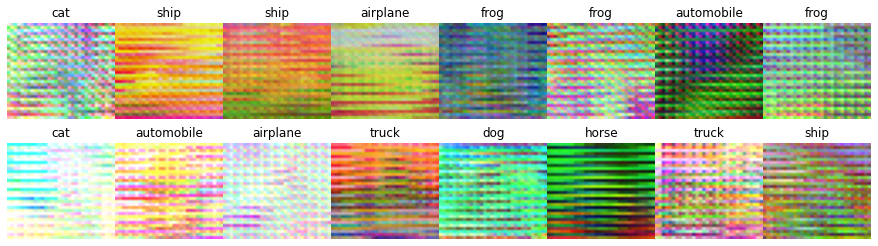

In [10]:
# after applying data augmentation with 50% probability
train_dataset = CustomDataset(train=True, prob=0.5)
test_dataset = CustomDataset(train=False, prob=0.5)

BATCH_SIZE = 64

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True, 
                          collate_fn=train_dataset.collate_fn)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=False, 
                         collate_fn=test_dataset.collate_fn)

CIFAR_plot_dataset(test_loader)

In [14]:
# ----- ConvNet Image Classification -----

In [15]:
class ConvNet(nn.Module):
    """
    - stack [Conv2D + Conv2D + MaxPool2D] at least three times
    - follwed by at least three Linear layers
    - 3x3 filter is enough, but feel free to use larger filter size
    - channels used: [10, 32, 64, 128, 256, 512, 1024
    - The model may include BatchNormalization, regularizers, and Dropout, but they are not necessary
    """
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), # -> 32*32*32
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=2, stride=2), # -> 64*16*16
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2), # -> 64*8*8
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*8*8, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 10)  
        )

    def forward(self, x):
        """
        Inputs
        - x: batch of input images.
        Returns
        - softmax probabilites of the input image for each class label
        """
        x = self.conv(x)
        return x

In [16]:
# Make sure your runtime type is GPU and you are using PyTorch version higher than 1.8!
DEVICE = torch.device('cuda') if torch.cuda.is_available else torch.device('cpu')
print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.7.1, Device: cuda


In [17]:
# define model
EPOCHS = 10
model = ConvNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(model)

ConvNet(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=1024, bias=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=256, bias=True)
    (10): ReLU()
    (11): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [18]:
# train
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tModel: ConvNet, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))

0it [00:00, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]


[EPOCH: 1], 	Model: ConvNet, 	Test Loss: 0.0238, 	Test Accuracy: 45.52 % 



0it [00:00, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/157 [00:00<?, ?it/s]


[EPOCH: 9], 	Model: ConvNet, 	Test Loss: 0.0214, 	Test Accuracy: 56.23 % 



0it [00:00, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]


[EPOCH: 10], 	Model: ConvNet, 	Test Loss: 0.0223, 	Test Accuracy: 56.10 % 

